# Merge and clean

This notebook cleans datasets (ECML, HTTPParams and XSS) and finally merges them to one bigger dataset.

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent styling for all plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [17]:
with open('ECML.json', 'r') as f:
    ecml = json.load(f)

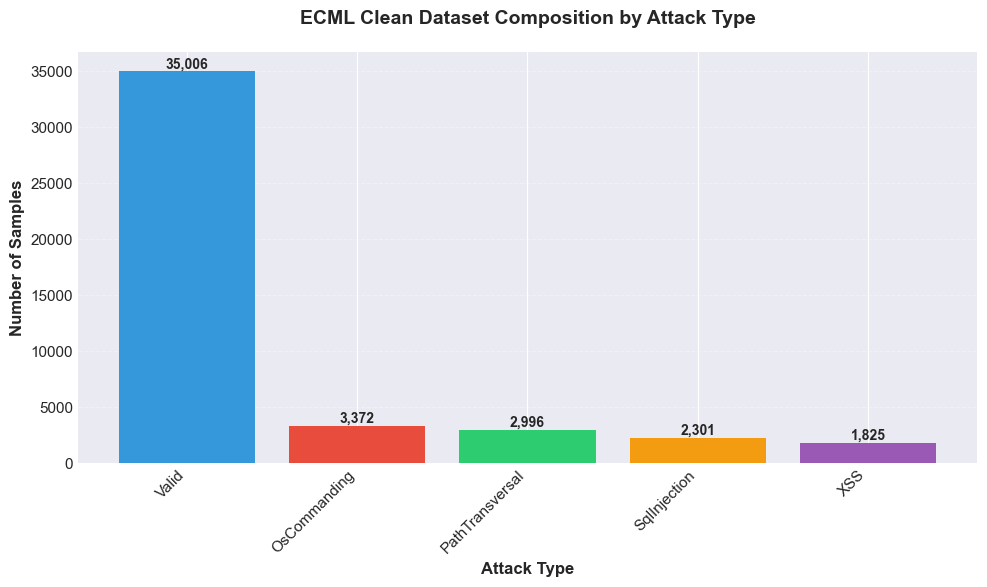

ECML Total samples: 45,500


In [18]:
# Display first 10 rows
ecml[:10]

# Visualize ECML dataset composition
ecml_df = pd.DataFrame(ecml)
type_counts = ecml_df['type'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(type_counts.index, type_counts.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
plt.title('ECML Clean Dataset Composition by Attack Type', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"ECML Total samples: {len(ecml):,}")

In [19]:
with open('HTTPParams.json', 'r') as f:
    custom = json.load(f)

In [ ]:
# Display first 10 rows
custom[:10]

# Visualize HTTPParams dataset composition (raw, pre-cleaning: column is
# 'attack_type' here - 'type' only exists after prepare_custom() runs below)
custom_df = pd.DataFrame(custom)
type_counts = custom_df['attack_type'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(type_counts.index, type_counts.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'])
plt.title('HTTPParams Raw Dataset Composition by Attack Type', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"HTTPParams Total samples: {len(custom):,}")

In [21]:
with open('xss.json', 'r') as f:
    xss = json.load(f)

In [ ]:
# Display first 10 rows
xss[:10]

# Visualize XSS dataset composition (raw, pre-cleaning: column is 'Label'
# (0/1) here - 'type' only exists after prepare_xss() runs below)
xss_df = pd.DataFrame(xss)
type_counts = xss_df['Label'].value_counts().sort_index()
label_names = ['Valid (0)', 'XSS (1)']
colors = ['#3498db', '#e74c3c']
plt.figure(figsize=(10, 6))
bars = plt.bar(label_names, type_counts.values, color=colors)
plt.title('XSS Raw Dataset Composition by Label', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Label', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"XSS Total samples: {len(xss):,}")

In [23]:
import urllib.parse

def unquote(text):
    k = 0
    uq_prev = text
    while(k < 100):
        uq = urllib.parse.unquote_plus(uq_prev)
        if uq == uq_prev:
            break
        else:
            uq_prev = uq
    
    return uq_prev

def remove_new_line(text):
    text = text.strip()
    text = ' '.join(text.splitlines())
    
    return text

def remove_multiple_whitespaces(text):
    return ' '.join(text.split())

def clean_pattern(pattern):
    pattern = unquote(pattern)
    pattern = remove_new_line(pattern)
    pattern = pattern.lower()
    pattern = remove_multiple_whitespaces(pattern)
    
    return pattern

def prepare_ecml(x):
    out = {}
    out['pattern'] = clean_pattern(x['request'])
    if x['type'] == 'Valid':
        out['type'] = 'valid'
    elif x['type'] == 'XSS':
        out['type'] = 'xss'
    elif x['type'] == 'SqlInjection':
        out['type'] = 'sqli'
    elif x['type'] == 'PathTransversal':
        out['type'] = 'path-traversal'
    elif x['type'] == 'OsCommanding':
        out['type'] = 'cmdi'
    return out

def prepare_custom(x):
    out = {}
    
    out['pattern'] = clean_pattern(x['payload'])
    if x['attack_type'] == 'norm':
        out['type'] = 'valid'
    else:
        out['type'] = x['attack_type']
    return out

def prepare_xss(x):
    out = {}
    
    out['pattern'] = clean_pattern(x['Sentence'])
    if x['Label'] == 1:
        out['type'] = 'xss'
    else:
        out['type'] = 'valid'
    return out

In [24]:
ecml = list(map(prepare_ecml, ecml))

In [25]:
custom = list(map(prepare_custom, custom))

In [26]:
xss = list(map(prepare_xss, xss))

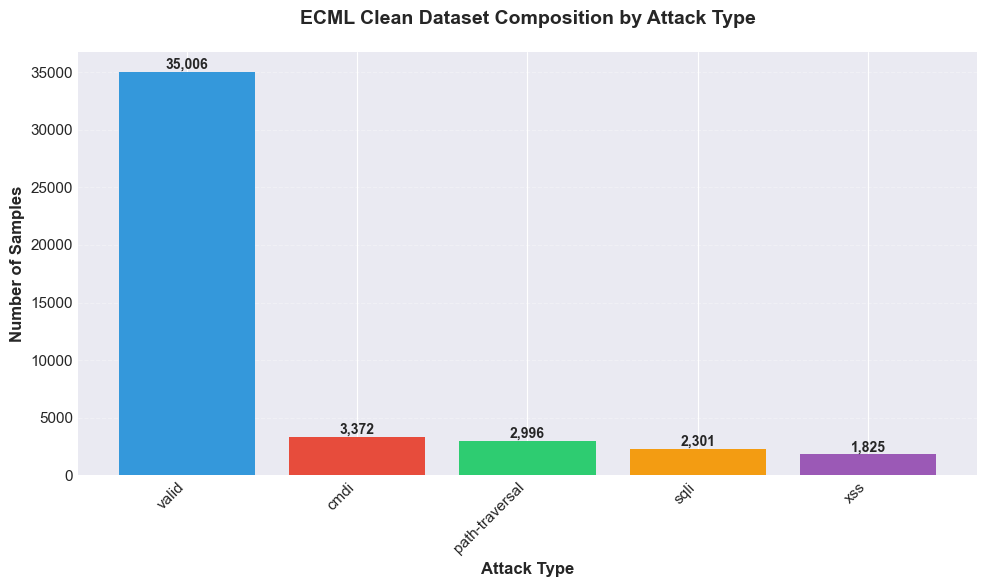

ECML Clean Total samples: 45,500


In [27]:
# Display first 10 rows
ecml[:10]

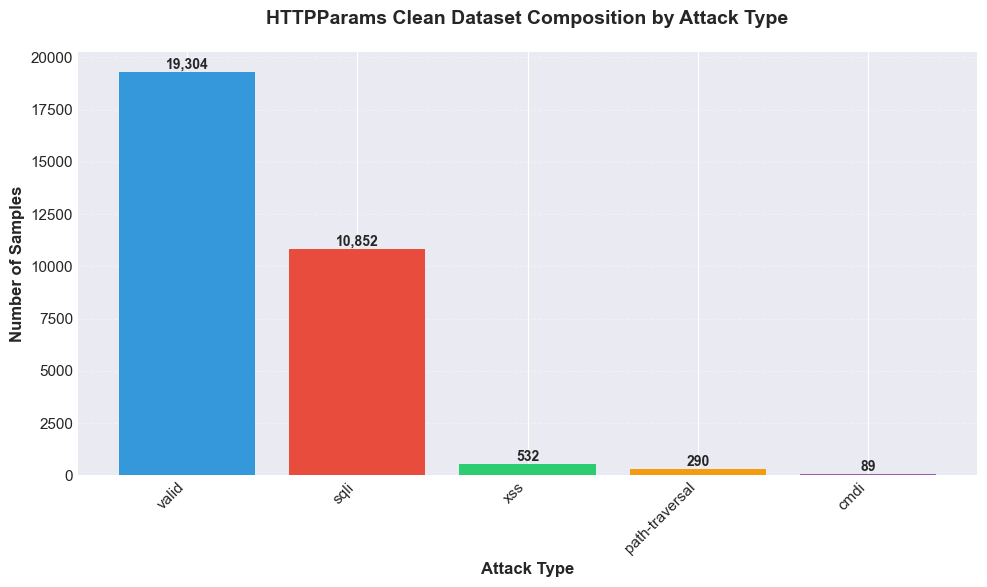

HTTPParams Clean Total samples: 31,067


In [28]:
# Display first 10 rows
custom[:10]

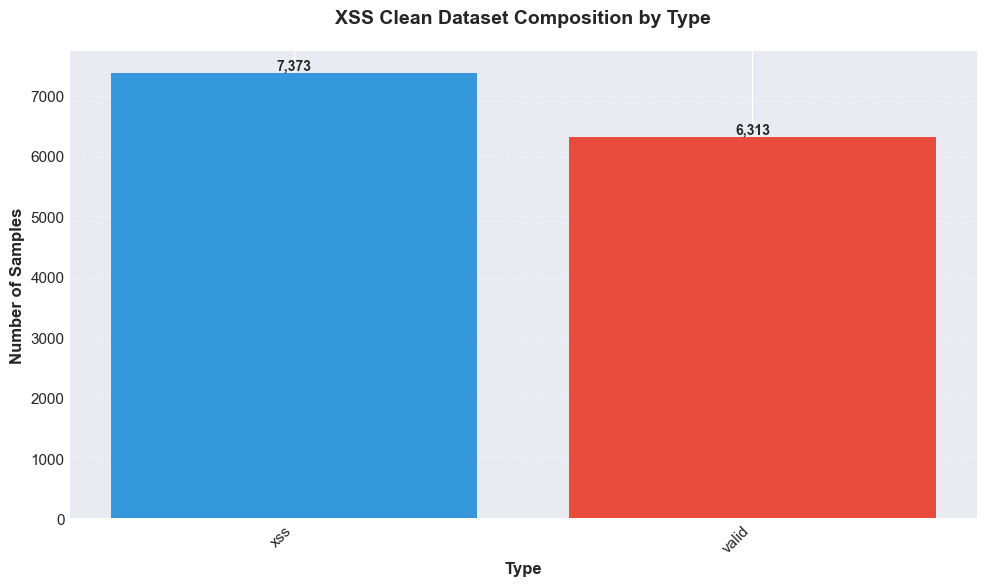

XSS Clean Total samples: 13,686


In [ ]:
# Display first 10 rows
xss[:10]

# Visualize XSS cleaned dataset composition
xss_df = pd.DataFrame(xss)
type_counts = xss_df['type'].value_counts()

# Order: Valid first, then XSS
ordered_types = ['valid', 'xss']
ordered_counts = [type_counts.get('valid', 0), type_counts.get('xss', 0)]
colors = ['#3498db', '#e74c3c']  # Blue for valid, Red for xss

plt.figure(figsize=(10, 6))
bars = plt.bar(ordered_types, ordered_counts, color=colors)
plt.title('XSS Clean Dataset Composition by Type', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"XSS Clean Total samples: {len(xss):,}")

In [30]:
with open('ecml_clean.json', 'w') as f:
    json.dump(ecml, f)

In [31]:
with open('HTTPParams_clean.json', 'w') as f:
    json.dump(custom, f)

In [32]:
with open('xss_clean.json', 'w') as f:
    json.dump(xss, f)

In [33]:
complete_clean = ecml+custom+xss

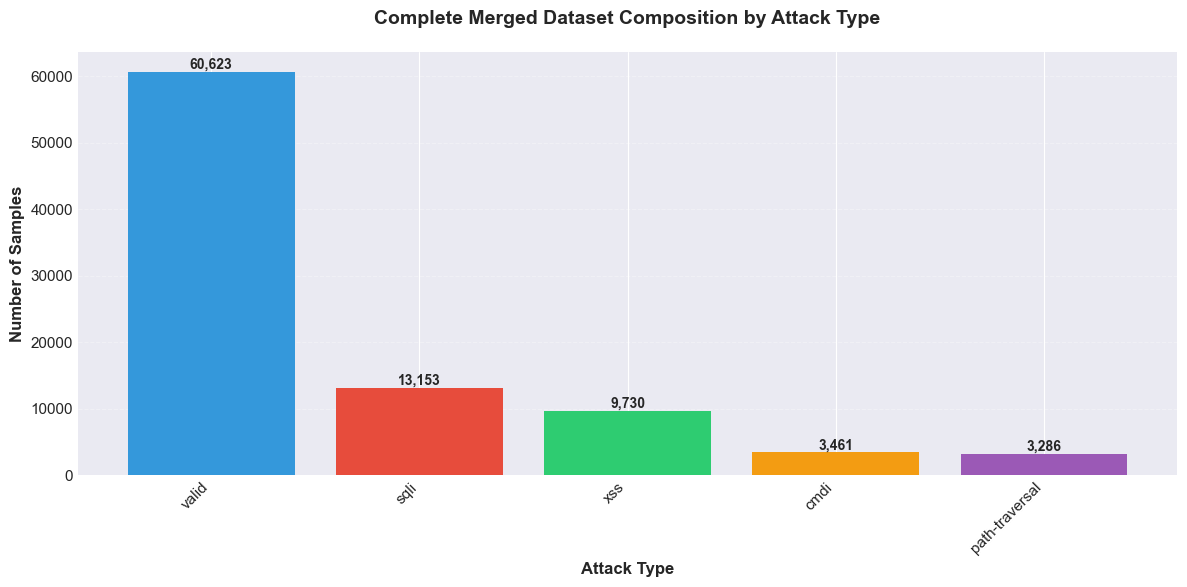


Complete Dataset Statistics:
Total samples: 90,253

Class distribution:
  valid: 60,623 (67.17%)
  sqli: 13,153 (14.57%)
  xss: 9,730 (10.78%)
  cmdi: 3,461 (3.83%)
  path-traversal: 3,286 (3.64%)

Dataset Source Breakdown:
  ECML: 45,500 samples
  HTTPParams: 31,067 samples
  XSS: 13,686 samples


In [34]:
# Display first 10 rows
complete_clean[:10]

# Visualize complete merged dataset composition
complete_df = pd.DataFrame(complete_clean)
type_counts = complete_df['type'].value_counts()
plt.figure(figsize=(12, 6))
bars = plt.bar(type_counts.index, type_counts.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22'])
plt.title('Complete Merged Dataset Composition by Attack Type', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Display comprehensive statistics
print(f"\nComplete Dataset Statistics:")
print(f"Total samples: {len(complete_clean):,}")
print(f"\nClass distribution:")
for attack_type, count in type_counts.items():
    percentage = (count / len(complete_clean)) * 100
    print(f"  {attack_type}: {count:,} ({percentage:.2f}%)")

# Dataset source breakdown
print(f"\nDataset Source Breakdown:")
print(f"  ECML: {len(ecml):,} samples")
print(f"  HTTPParams: {len(custom):,} samples")
print(f"  XSS: {len(xss):,} samples")

In [35]:
with open('complete_clean.json', 'w') as f:
    json.dump(complete_clean, f)

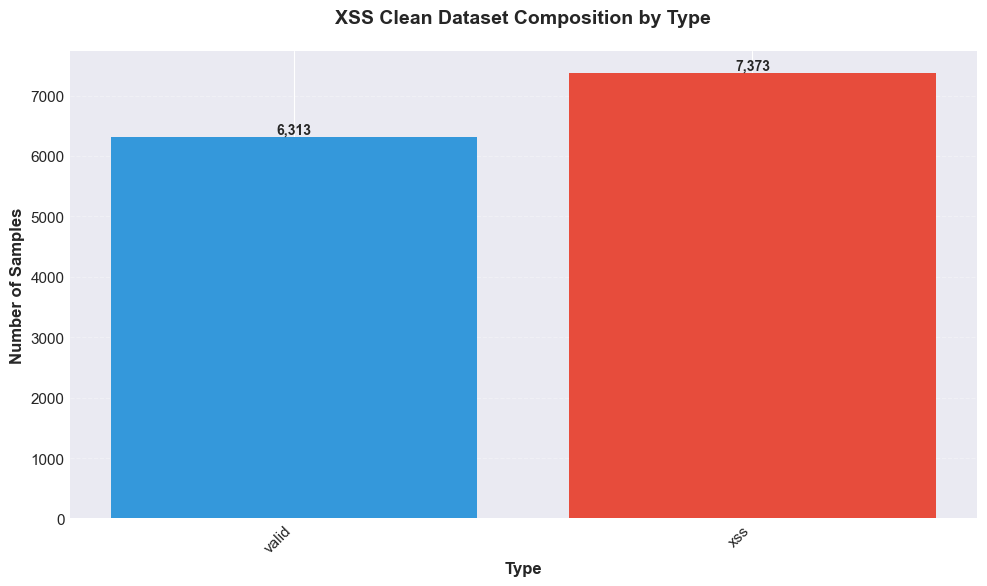

XSS Clean Total samples: 13,686


In [36]:
# Visualize XSS cleaned dataset composition
xss_df = pd.DataFrame(xss)
type_counts = xss_df['type'].value_counts()

# Order: Valid first, then XSS
ordered_types = ['valid', 'xss']
ordered_counts = [type_counts.get('valid', 0), type_counts.get('xss', 0)]
colors = ['#3498db', '#e74c3c']  # Blue for valid, Red for xss

plt.figure(figsize=(10, 6))
bars = plt.bar(ordered_types, ordered_counts, color=colors)
plt.title('XSS Clean Dataset Composition by Type', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"XSS Clean Total samples: {len(xss):,}")